# Wake Impedance with Pooled Kicks

This notebook walks new BLonD users through a **realistic SPS simulation including intensity effects** — the collective forces that the beam exerts on itself through the impedance of the surrounding vacuum chamber.

It is adapted from the script `blond/examples/scripts/EX_05_Wake_impedance_pooled.py` and adds:

- explanatory text for each step,
- visualisations of the resonator spectrum, the line density, the induced voltage and the bunch evolution.

## What we will simulate

A single proton bunch in the **CERN SPS**:

| Parameter         | Value                  |
|-------------------|------------------------|
| Circumference     | 6911.56 m              |
| Reference momentum| 25.92 GeV/c            |
| RF harmonic       | 4620                   |
| RF voltage        | 0.9 MV                 |
| Bunch intensity   | 10¹⁰ protons           |
| Bunch length      | σ = 0.5 ns             |

The impedance is described by a **broad-band table of resonators** (the SPS "HQ" table).

## What is a *pooled* kick?

Every turn, both the RF cavity and the wake field apply a small momentum kick to each macroparticle by **interpolating a voltage curve** onto the particle's longitudinal position. If two elements do this independently the interpolation work is doubled.

`PooledInterpolationKick` collects the voltage contributions from several elements (here: RF + wake field), **sums them in voltage space**, and applies a single interpolated kick at the end of the turn. Physically the result is identical — only the run time changes.

## 1. Imports

Everything we need lives in the top-level `blond` package, except `PooledInterpolationKick` (still in `blond.experimental`) and the more detailed observation classes.

In [1]:
import time

import numpy as np
from matplotlib import pyplot as plt

from blond import (
    Beam,
    BeamHist2dOncePerTurn,
    ConstantMagneticCycle,
    DriftSimple,
    Resonators,
    Ring,
    Simulation,
    SingleHarmonicRFStation,
    StaticProfile,
    StaticProfileObservation,
    TimeDomainFftSolver,
    WakeField,
    momentum_compaction_factor,
    proton,
    setup_backend,
    BeamStatisticsOncePerTurn,
    WakeFieldObservation,
    AllowPlotting,
)
from blond.experimental import PooledInterpolationKick
from blond.testing import pytest_active

pytest_is_active = pytest_active()

if not pytest_is_active:  # pragma: no cover
    setup_backend("auto")

Using environment variable BLOND_BACKEND_MODE = python
Changing backend to `Numpy64Bit`
Changing backend to `Cupy64Bit`
Set special to `cuda`
Set special to `cuda`


/home/slauber/PycharmProjects/deleteme/blonder/blond/experimental/__init__.py:40: ExperimentalFeaturesWarning: 
Importing experimental features. These are under development and are
liable to change or be removed without warning.

  warnings.warn(_msg, ExperimentalFeaturesWarning, stacklevel=1)


## 2. Load the impedance source

The SPS impedance is represented by **resonators**, each characterised by three numbers:

- `R_shunt` — shunt impedance [Ω]
- `f_res`   — resonant frequency [Hz]
- `Q`       — quality factor (sharpness of the resonance)

The combined impedance of $N$ resonators is

$$ Z(f) = \sum_{k=1}^{N} \frac{R_{\text{s},k}}{1 + j Q_k \left( \frac{f}{f_{\text{res},k}} - \frac{f_{\text{res},k}}{f} \right)}. $$

Below we read the table and plot the impedance to get a feel for which frequencies the beam will be affected by.

In [2]:
from pathlib import Path
import blond

resource_path = (
    Path(blond.__file__).parent
    / "examples"
    / "scripts"
    / "resources"
    / "EX_05_new_HQ_table.txt"
)
resonator_data = np.loadtxt(resource_path, comments="!")

f_res = resonator_data[:, 0] * 1e9  # GHz -> Hz
Q_factor = resonator_data[:, 1]
R_shunt = resonator_data[:, 2] * 1e6  # MOhm -> Ohm

print(f"Loaded {len(R_shunt)} resonators")
print(
    f"Frequency range: {f_res.min() / 1e9:.2f} - {f_res.max() / 1e9:.2f} GHz"
)
print(f"Largest shunt impedance: {R_shunt.max() / 1e6:.2f} MΩ")

Loaded 52 resonators
Frequency range: 0.63 - 5.82 GHz
Largest shunt impedance: 0.81 MΩ


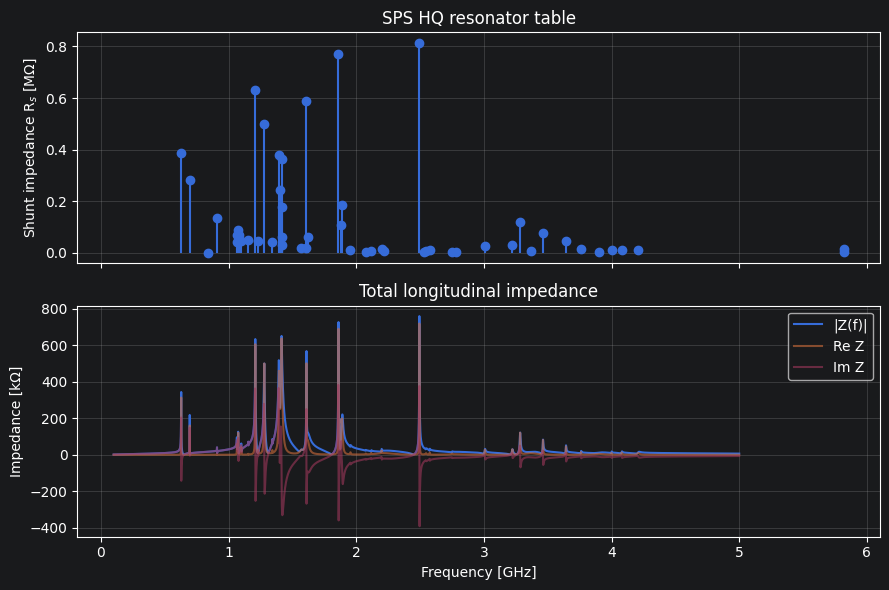

In [3]:
f_scan = np.linspace(1e8, 5e9, 5000)
Z = np.zeros_like(f_scan, dtype=complex)
for Rs, fr, Q in zip(R_shunt, f_res, Q_factor):
    Z += Rs / (1 + 1j * Q * (f_scan / fr - fr / f_scan))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.stem(
    f_res / 1e9, R_shunt / 1e6, basefmt=" ", linefmt="C0-", markerfmt="C0o"
)
ax1.set_ylabel("Shunt impedance R$_s$ [MΩ]")
ax1.set_title("SPS HQ resonator table")
ax1.grid(alpha=0.3)

ax2.plot(f_scan / 1e9, np.abs(Z) / 1e3, label="|Z(f)|")
ax2.plot(f_scan / 1e9, Z.real / 1e3, alpha=0.6, label="Re Z")
ax2.plot(f_scan / 1e9, Z.imag / 1e3, alpha=0.6, label="Im Z")
ax2.set_xlabel("Frequency [GHz]")
ax2.set_ylabel("Impedance [kΩ]")
ax2.set_title("Total longitudinal impedance")
ax2.legend(loc="best")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Build the machine

Now we describe the ring itself:

- a **`Ring`** with the SPS circumference,
- a **`ConstantMagneticCycle`** – we are running on a flat top, no acceleration,
- a **`DriftSimple`** carrying the momentum compaction factor,
- a **`Beam`** of 10¹⁰ protons,
- a **`StaticProfile`** that slices a single RF bucket into 256 bins.

In [4]:
# [eV/c]
ring = Ring(circumference=6911.56)

magnetic_cycle = ConstantMagneticCycle(
    reference_particle=proton,
    value=25.92e9,
    in_unit="momentum",
)

drift = DriftSimple(
    momentum_compaction_factor=momentum_compaction_factor(
        transition_gamma=22.82177322938192
    ),
    orbit_length=ring.circumference,
)

t_rev = magnetic_cycle.get_t_rev_init(
    circumference=ring.circumference,
    particle_type=magnetic_cycle.reference_particle,
)

harmonic_number = 4620
t_rf = t_rev / harmonic_number

profile = StaticProfile.from_rad(
    cut_left_rad=0,
    cut_right_rad=2 * np.pi,
    n_bins=2**8,
    t_period=t_rf,
)

print(f"Revolution period:  {t_rev * 1e6:.3f} µs")
print(f"RF bucket length:   {t_rf * 1e9:.3f} ns")
print(f"Profile bin width:  {(t_rf / 2**8) * 1e12:.2f} ps")

Revolution period:  23.070 µs
RF bucket length:   4.993 ns
Profile bin width:  19.51 ps


## 4. RF station + wake field with pooled kicks

Here is the pooling magic: we instantiate a single `PooledInterpolationKick` and hand it to **both** the RF station and the wake field via the `delayed_kick=` argument. They no longer apply their kicks themselves; instead, they each push their voltage contribution into the pool, and the pool applies the combined kick once per turn.

The `delayed_kick_time_axis` tells the pool which time grid the contributions are defined on — here, the same grid as the profile.

### Pooled vs. non-pooled: a subtle physics difference

It is worth noticing that **pooling changes how the RF kick is computed**, not just when it is applied:

- **Without pooling** (`delayed_kick=None`), `SingleHarmonicRFStation` evaluates the kick analytically for every macroparticle,
  $$\Delta E_i \;=\; q\,V\,\sin\bigl(h\,\omega_{0}\,\Delta t_i + \varphi_{\text{rf}}\bigr).$$
  This is the **exact** smooth sinusoid, sampled at each particle's position.

- **With pooling**, the RF voltage curve is first tabulated on `delayed_kick_time_axis` (the profile grid), summed with the wake-field voltage, and then **linearly interpolated** onto each particle's position. The wake voltage was already a tabulated quantity, so it costs nothing to pool with it — but the RF contribution silently becomes a piecewise-linear approximation of the sinusoid.

In practice, with 256 bins per RF bucket the interpolation error is tiny (well below the wake-induced effects we want to study) and pooling wins on speed. Be aware of the trade-off though: if you ever want to study very small RF non-linearities without wake fields, prefer the non-pooled mode so the kick stays exact.

In [5]:
pooled_kick = PooledInterpolationKick()

rf_station = SingleHarmonicRFStation(
    harmonic=harmonic_number,
    voltage=0.9e6,
    phi_rf=0.0,
    delayed_kick=pooled_kick,
    delayed_kick_time_axis=profile.hist_x,
)

wakefield = WakeField(
    sources=(Resonators(R_shunt, f_res, Q_factor),),
    solver=TimeDomainFftSolver(),
    profile=profile,
    delayed_kick=pooled_kick,
)

## 5. Assemble the simulation

We add every element to the ring and pass everything to `Simulation`.

`reorder=True` lets BLonD sort drifts/RF/wakefields/profiles into the canonical execution order.

`sim.print_one_turn_execution_order()` is the best sanity check when you set up a new simulation.

In [6]:
ring.add_elements((rf_station, wakefield, pooled_kick, drift), reorder=False)

sim = Simulation(ring=ring, magnetic_cycle=magnetic_cycle)
sim.print_one_turn_execution_order()

------------------------------------------------------------------------------
Execution order
---------------
element.name                             type                 section_index filtered_dict
Unnamed-SingleHarmonicRFStation-001      SingleHarmonicRFStation 0             {'intended_for_scheduling': {'harmonic', 'phi_rf_design', 'voltage'}, 'schedules': {}, 'schedule_active': False, 'each_turn_i': 1, 'active': True, 'observables': {}, 'cavity_feedback_list': [None], 'omega_rf_design': None, 'delta_omega_rf': 0.0, 'phi_rf_design': 0.0, 'delta_phi_rf': 0.0, 'voltage': 900000.0, 'harmonic': 4620}
 ↓ Unnamed-StaticProfile-001             StaticProfile        0             {'each_turn_i': 1, 'active': True, 'observables': {}, 'hist_y_to_density_factor': None, 'hist_step': 1.9505531625260388e-11, 'cut_left': -1.6155871338926322e-27, 'cut_right': 4.9934160960666585e-09, 'bin_edges': "<class 'cupy.ndarray'>(min=-1.6155871338926322e-27, max=4.9934160960666585e-09, shape=(257,))", 'gradie

## 6. Generate the bunch

`Beam.simple_gaussian` is a one-line factory that fills a beam with a **plain 2D Gaussian distribution** in $(\Delta t, \Delta E)$. We pick the widths ourselves:

- `dt_scale` — rms bunch length (here σ = 0.5 ns),
- `dE_scale` — rms energy spread (≈ 22 MeV, estimated below).

This is *not* a matched distribution: a Gaussian does not follow the contours of the non-linear RF Hamiltonian, so the bunch will breathe a little even without intensity effects. If you need a properly matched bunch (e.g. for emittance studies) use `SemiEmpiricMatcher`, which performs a full non-linear match to the actual RF (and, optionally, intensity-effect) Hamiltonian.

The energy spread used here is a small-amplitude (linearised) match,

$ \sigma_{E} \;=\; \sqrt{\frac{q\,V\,\beta^{2}\,E_{s}\bigl(1-\cos(h\,\omega_{0}\,\sigma_{t})\bigr)}{\pi\,h\,|\eta|}}, $

which is good enough to keep the bunch close to the synchronous orbit but not exactly stationary.

Under `pytest` we shrink the macroparticle count so the test suite stays fast.

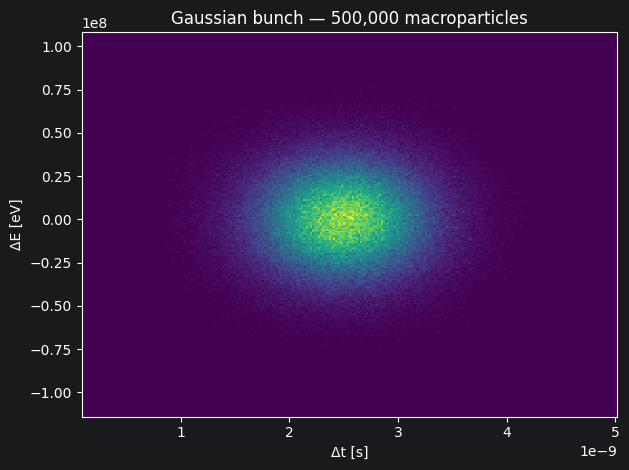

In [7]:
n_macroparticles = int(1e4) if pytest_is_active else int(5e5)

beam = Beam.simple_gaussian(
    n_macroparticles=n_macroparticles,
    intensity=1e10,
    particle_type=proton,
    dt_scale=2e-9 / 4,  # σ_t = 0.5 ns
    dE_scale=22e6,  # σ_E ≈ 22 MeV (linearised match)
    dt_offset=t_rf / 2,
    seed=1,
)

beam.plot_hist2d()
plt.title(f"Gaussian bunch — {n_macroparticles:,} macroparticles")
plt.xlabel("Δt [s]")
plt.ylabel("ΔE [eV]")
plt.tight_layout()
plt.show()

## 7. What to observe

Memory matters: storing the full $(dt, dE)$ for every particle and every turn quickly fills RAM. We use a mix of lightweight observers:

- `BeamStatisticsOncePerTurn` — just the rms bunch length, position and energy spread per turn,
- `BeamHist2dOncePerTurn` — a 2D histogram of the bunch every few turns (much smaller than the full coordinate set),
- `StaticProfileObservation` — the line-density profile,
- `WakeFieldObservation` — the induced voltage seen by the beam.

In [8]:
n_turns = 200 if pytest_is_active else 6000
hist_every = max(1, n_turns // 20)

stats_obs = BeamStatisticsOncePerTurn(each_turn_i=1)
hist_obs = BeamHist2dOncePerTurn(
    each_turn_i=hist_every,
    bins=128,
    range=[[0, t_rf], [-3e8, 3e8]],
)
profile_obs = StaticProfileObservation(each_turn_i=hist_every, profile=profile)
wake_obs = WakeFieldObservation(each_turn_i=hist_every, wakefield=wakefield)

## 8. Run the simulation


In [9]:
t0 = time.time()
sim.run_simulation(
    beams=(beam,),
    n_turns=n_turns,
    observe=(stats_obs, hist_obs, profile_obs, wake_obs),
)
print(f"Simulated {n_turns} turns in {time.time() - t0:.2f} s")


Beam 0 has 500.00k macroparticles 12.00MB
n_turns=6000
n_elements=4


BLonD3 mainloop: 100%|██████████| 6000/6000 [00:09<00:00, 604.49it/s, 3.275257ns per particle]

Simulated 6000 turns in 9.95 s


## 9. Look at the results

### 9.1 How does the bunch shape evolve?

We compare the matched bunch (turn 0) with the bunch at the end of the simulation. The wake field has now had hundreds of turns to distort the bunch.

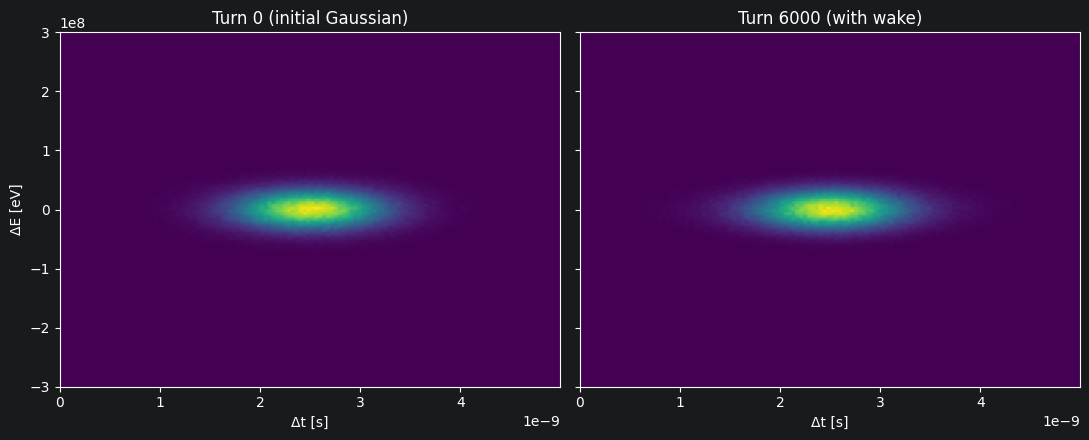

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, idx, title in zip(
    axes, (0, -1), ("Turn 0 (initial Gaussian)", f"Turn {n_turns} (with wake)")
):
    plt.sca(ax)
    hist_obs.plot(result_idx=idx)
    ax.set_title(title)
    ax.set_xlabel("Δt [s]")
axes[0].set_ylabel("ΔE [eV]")
plt.tight_layout()
plt.show()

### 9.2 Line-density evolution

A waterfall plot of the longitudinal line density makes it easy to see whether the bunch is shifting, stretching or oscillating.

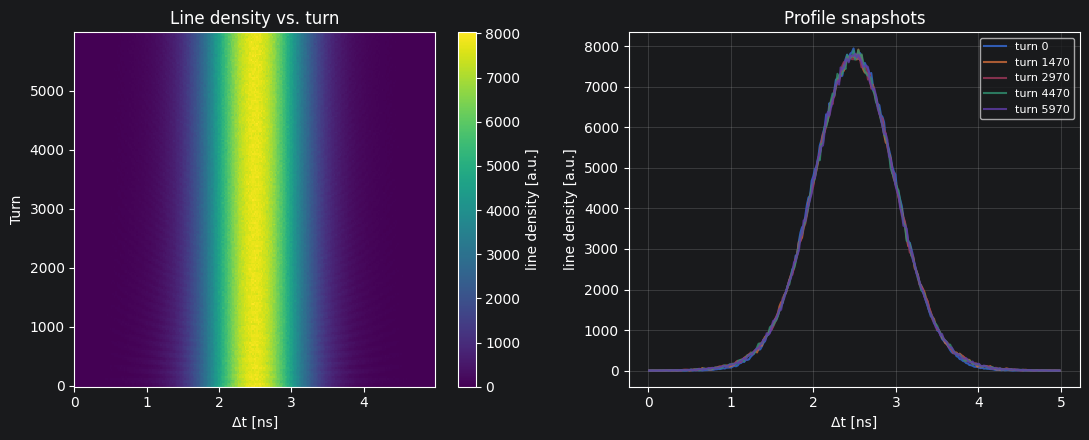

In [11]:
lines = profile_obs.hist_y
x_ns = profile_obs.hist_x * 1e9
turn_axis = profile_obs.turns_array

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

im = ax1.pcolormesh(x_ns, turn_axis, lines, shading="auto", cmap="viridis")
ax1.set_xlabel("Δt [ns]")
ax1.set_ylabel("Turn")
ax1.set_title("Line density vs. turn")
fig.colorbar(im, ax=ax1, label="line density [a.u.]")

for k, idx in enumerate(np.linspace(0, lines.shape[0] - 1, 5, dtype=int)):
    ax2.plot(x_ns, lines[idx], label=f"turn {idx * hist_every}", alpha=0.8)
ax2.set_xlabel("Δt [ns]")
ax2.set_ylabel("line density [a.u.]")
ax2.set_title("Profile snapshots")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 9.3 Induced voltage

The induced voltage is what the wake field actually adds to the RF voltage seen by each particle. Compared to the 0.9 MV RF voltage, it is typically much smaller — but it is *coherent* with the bunch and so can drive instabilities over many turns.

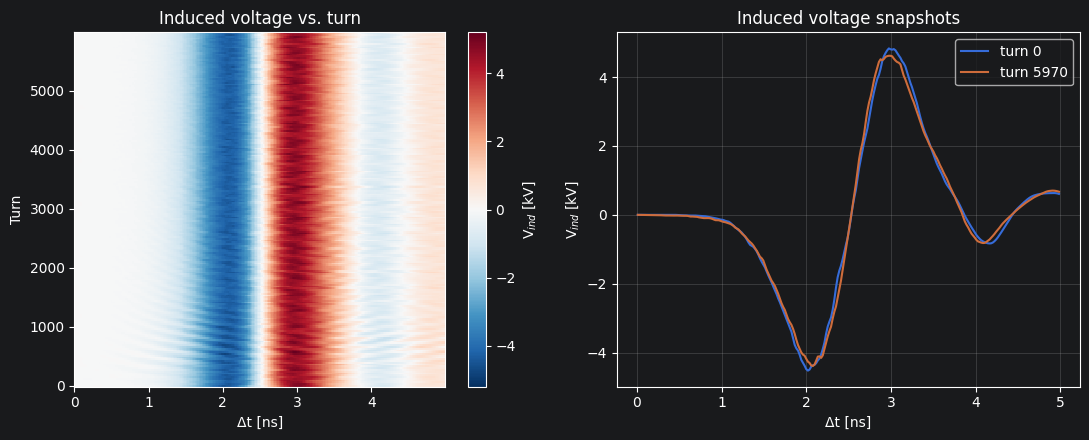

In [12]:
vind = wake_obs.induced_voltage

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

im = ax1.pcolormesh(
    x_ns,
    turn_axis,
    vind / 1e3,
    shading="auto",
    cmap="RdBu_r",
    vmin=-np.abs(vind).max() / 1e3,
    vmax=np.abs(vind).max() / 1e3,
)
ax1.set_xlabel("Δt [ns]")
ax1.set_ylabel("Turn")
ax1.set_title("Induced voltage vs. turn")
fig.colorbar(im, ax=ax1, label="V$_{ind}$ [kV]")

ax2.plot(x_ns, vind[0] / 1e3, label="turn 0")
ax2.plot(x_ns, vind[-1] / 1e3, label=f"turn {turn_axis[-1]}")
ax2.set_xlabel("Δt [ns]")
ax2.set_ylabel("V$_{ind}$ [kV]")
ax2.set_title("Induced voltage snapshots")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 9.4 Bunch length, position and energy spread

These three scalar diagnostics are the typical "first look" at the result of any longitudinal-dynamics simulation:

- *bunch length* — for a perfectly matched bunch this would be flat; the Gaussian we started from oscillates because it does not follow the non-linear bucket contours, and the wake field can amplify or damp those oscillations.
- *bunch position* — a steady shift means the bunch is moving relative to the synchronous phase (potential-well distortion).
- *energy spread* — indicates emittance growth.

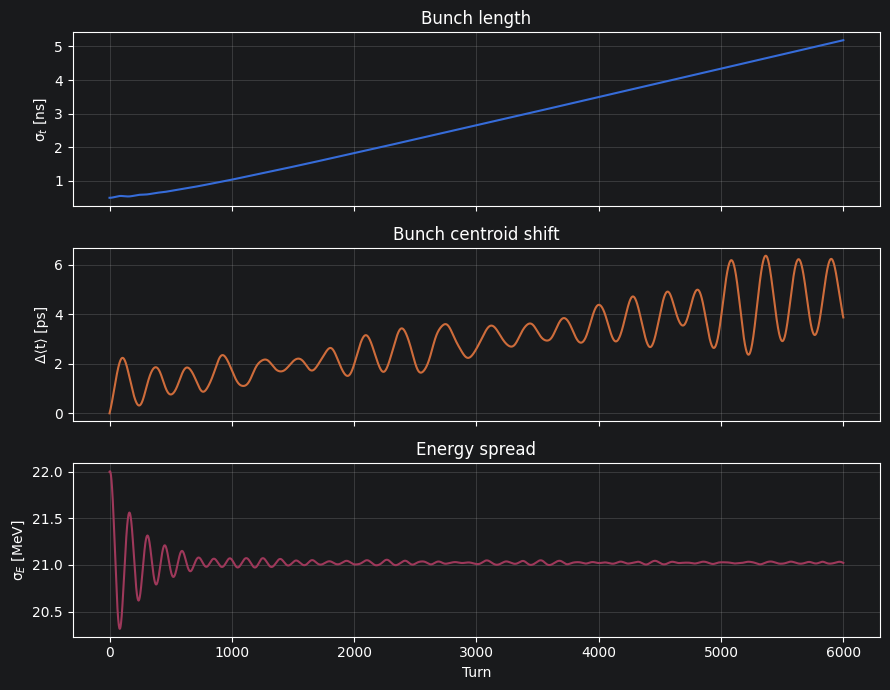

In [13]:
turns = np.arange(len(stats_obs.bunch_length))

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)

axes[0].plot(turns, stats_obs.bunch_length * 1e9, color="C0")
axes[0].set_ylabel("σ$_t$ [ns]")
axes[0].set_title("Bunch length")
axes[0].grid(alpha=0.3)

axes[1].plot(
    turns,
    (stats_obs.bunch_position - stats_obs.bunch_position[0]) * 1e12,
    color="C1",
)
axes[1].set_ylabel("Δ⟨t⟩ [ps]")
axes[1].set_title("Bunch centroid shift")
axes[1].grid(alpha=0.3)

axes[2].plot(turns, stats_obs.energy_spread / 1e6, color="C2")
axes[2].set_ylabel("σ$_E$ [MeV]")
axes[2].set_xlabel("Turn")
axes[2].set_title("Energy spread")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Where to go next

- Switch off the pooling (`delayed_kick=None` on both the RF station and the wake field, and drop `pooled_kick` from the ring) and compare the run time — the physics should be identical.
- Try a different solver: `PeriodicFreqSolver(t_periodicity=t_rev)` for a frequency-domain solver.
- Increase the intensity by 10× and watch the bunch deform much more strongly.
- Add `RFStationPhaseObservation` to track the RF phase if you switch on acceleration via `MagneticCyclePerTurn`.
- See `EX_02_Main_long_ps_booster.py` for a multi-source impedance setup and `EX_05_Wake_impedance.py` for an analytical cross-check of the induced voltage.